# Clasificación de fatiga muscular usando señales EMG

En este notebook se desarrolla un sistema de clasificación de fatiga muscular a partir de señales electromiográficas (EMG).  

Se realiza:
- Preprocesamiento de señales
- Extracción de características
- Análisis exploratorio de datos (EDA)
- Entrenamiento de modelos de Machine Learning
- Evaluación y comparación de resultados

El objetivo es identificar patrones que permitan distinguir entre estados de fatiga y no fatiga.

In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn scipy tensorflow datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


## Carga del dataset

Se carga el dataset de señales EMG correspondiente a diferentes músculos durante actividad física.  
Este dataset contiene múltiples canales y una variable objetivo que indica la presencia de fatiga.

In [2]:
from datasets import load_dataset

dataset = load_dataset("YominE/Muscle_Fatigue_Cycling")
df = dataset['train'].to_pandas()

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Definición de parámetros

Se define la frecuencia de muestreo y el tamaño de ventana.  
Las señales se segmentan en ventanas de 1 segundo para facilitar la extracción de características.

In [3]:
fs = 1000
window_size = fs

channels = [
    'Right Rectus femoris',
    'Left Gluteus maximus',
    'Left Gastrocnemius medialis',
    'Left Semitendinosus',
    'Left Biceps femoris caput longus',
    'Right Vastus medialis',
    'Right Tibialis anterior',
    'Left Gastrocnemius lateralis'
]
n_windows = len(df) // window_size

print("Total muestras:", len(df))
print("Ventanas:", n_windows)

Total muestras: 3002137
Ventanas: 3002


## Extracción de características

Se implementa una función que extrae características estadísticas y espectrales de cada ventana de la señal EMG, como:

- RMS (Root Mean Square)
- Varianza
- Zero Crossing Rate
- Mean Absolute Value
- Potencia espectral
- Frecuencia media y mediana

Estas características permiten representar la señal de forma compacta para el entrenamiento de modelos.

In [4]:
from scipy.signal import welch

def extraer_caracteristicas(ventana, fs=1000):

    rms = np.sqrt(np.mean(ventana**2))
    varianza = np.var(ventana)
    zcr = np.sum(np.diff(np.sign(ventana)) != 0)
    mav = np.mean(np.abs(ventana))

    freqs, psd = welch(ventana, fs=fs)
    
    pot_total = np.sum(psd)
    frec_media = np.sum(freqs * psd) / np.sum(psd)
    
    pot_acum = np.cumsum(psd)
    idx_median = np.searchsorted(pot_acum, pot_acum[-1] / 2)
    frec_mediana = freqs[idx_median]

    return [rms, varianza, zcr, mav, pot_total, frec_media, frec_mediana]

## Construcción del nuevo dataset

Se recorren las ventanas de la señal y se calculan las características para cada canal.  
El resultado es un nuevo dataset donde cada fila representa una ventana y sus respectivas características.

In [5]:
filas = []

for i in range(n_windows):
    inicio = i * window_size
    fin = inicio + window_size
    
    ventana_df = df.iloc[inicio:fin]
    fila = {}
    
    for canal in channels:
        ventana = ventana_df[canal].values
        feats = extraer_caracteristicas(ventana, fs)
        
        nombres = ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']
        
        for nombre, valor in zip(nombres, feats):
            fila[f'{canal}_{nombre}'] = valor

    fila['target'] = ventana_df['Target'].mode()[0]
    filas.append(fila)

nuevo_df = pd.DataFrame(filas)
nuevo_df.head()

,Right Rectus femoris_rms,Right Rectus femoris_var,Right Rectus femoris_zcr,Right Rectus femoris_mav,Right Rectus femoris_pot,Right Rectus femoris_f_media,Right Rectus femoris_f_mediana,Left Gluteus maximus_rms,Left Gluteus maximus_var,Left Gluteus maximus_zcr,...,Right Tibialis anterior_f_media,Right Tibialis anterior_f_mediana,Left Gastrocnemius lateralis_rms,Left Gastrocnemius lateralis_var,Left Gastrocnemius lateralis_zcr,Left Gastrocnemius lateralis_mav,Left Gastrocnemius lateralis_pot,Left Gastrocnemius lateralis_f_media,Left Gastrocnemius lateralis_f_mediana,target
0,0.011706,0.000137,123,0.008125,0.000037,54.570839,50.78125,0.003989,0.000016,122,...,90.848194,93.75000,0.025655,0.000658,120,0.019441,0.000127,59.538860,50.78125,0
1,0.014023,0.000197,111,0.010118,0.000045,55.855995,54.68750,0.004223,0.000018,120,...,86.074709,82.03125,0.031409,0.000986,149,0.021678,0.000294,79.432906,78.12500,0
2,0.014820,0.000220,121,0.010151,0.000051,54.184637,46.87500,0.004209,0.000018,126,...,85.845206,85.93750,0.026209,0.000687,101,0.020389,0.000219,58.352164,54.68750,0
3,0.013817,0.000191,121,0.009894,0.000053,57.536178,46.87500,0.004374,0.000019,115,...,86.521514,85.93750,0.021673,0.000470,154,0.015846,0.000133,86.660433,93.75000,0
4,0.013326,0.000177,122,0.009676,0.000045,58.618736,46.87500,0.004641,0.000022,120,...,88.026780,93.75000,0.025220,0.000636,138,0.019283,0.000181,76.983962,78.12500,0


In [6]:
nuevo_df['target'] = nuevo_df['target'].replace({2:1})
nuevo_df['target'].value_counts()

target
0    2128
1     874
Name: count, dtype: int64

## Análisis Exploratorio de Datos (EDA)

Se analizan las distribuciones de las variables, correlaciones y la relación con la variable objetivo.  
Esto permite entender la estructura de los datos y detectar patrones relevantes.

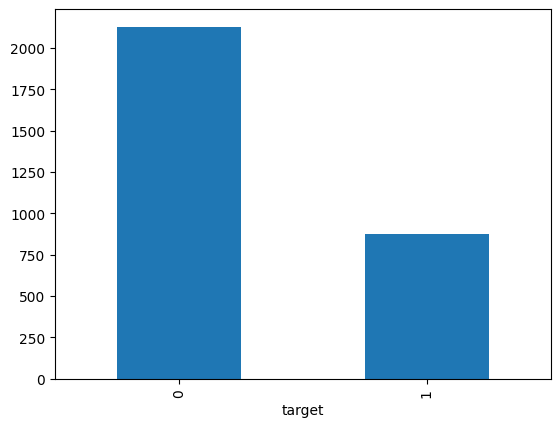

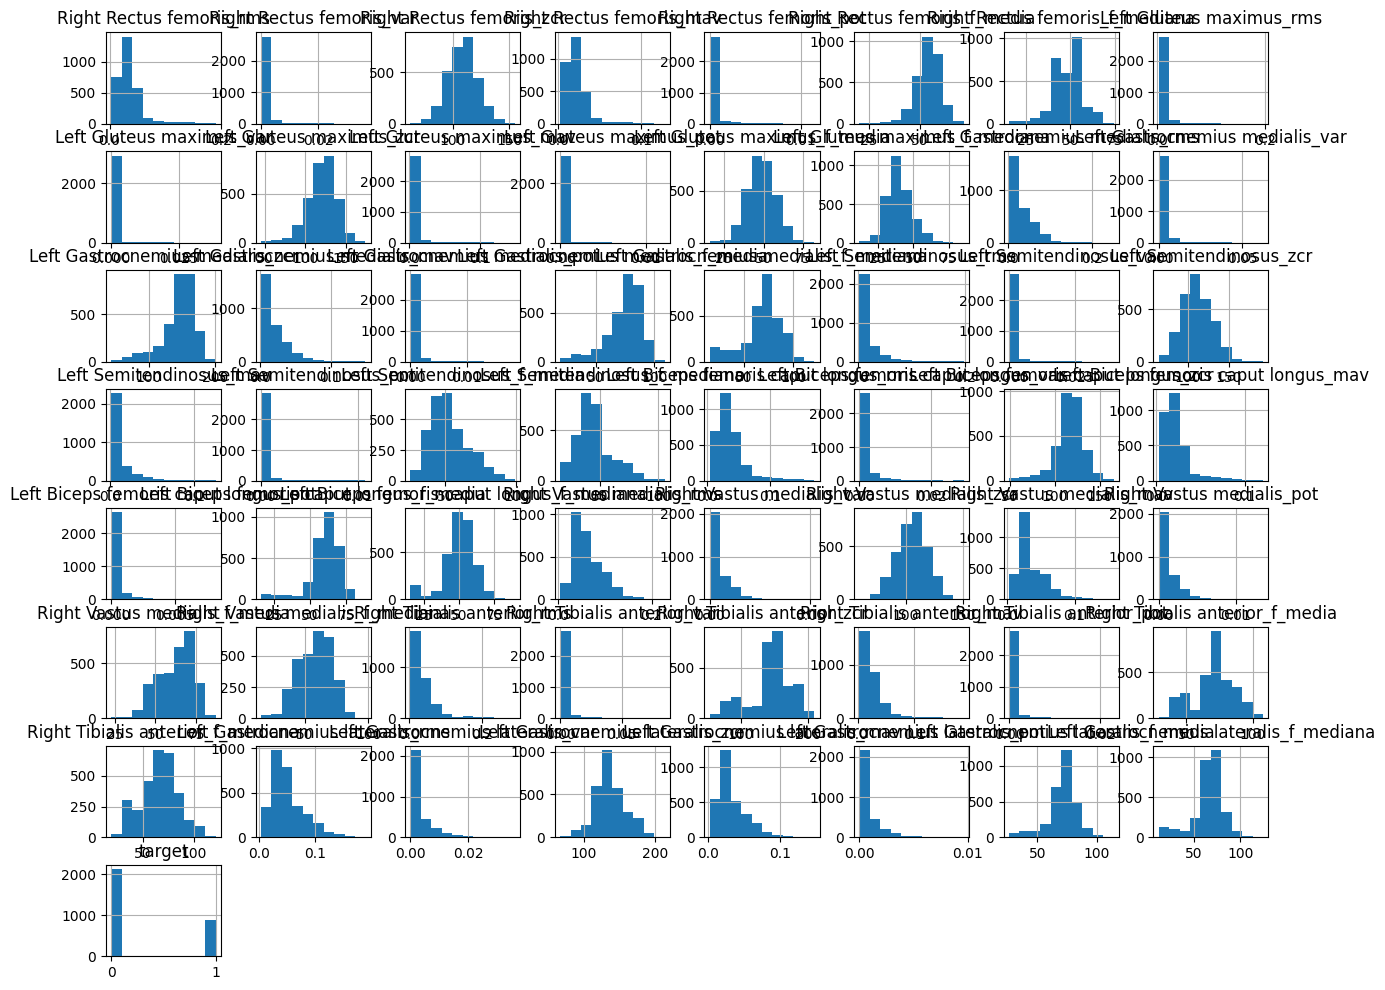

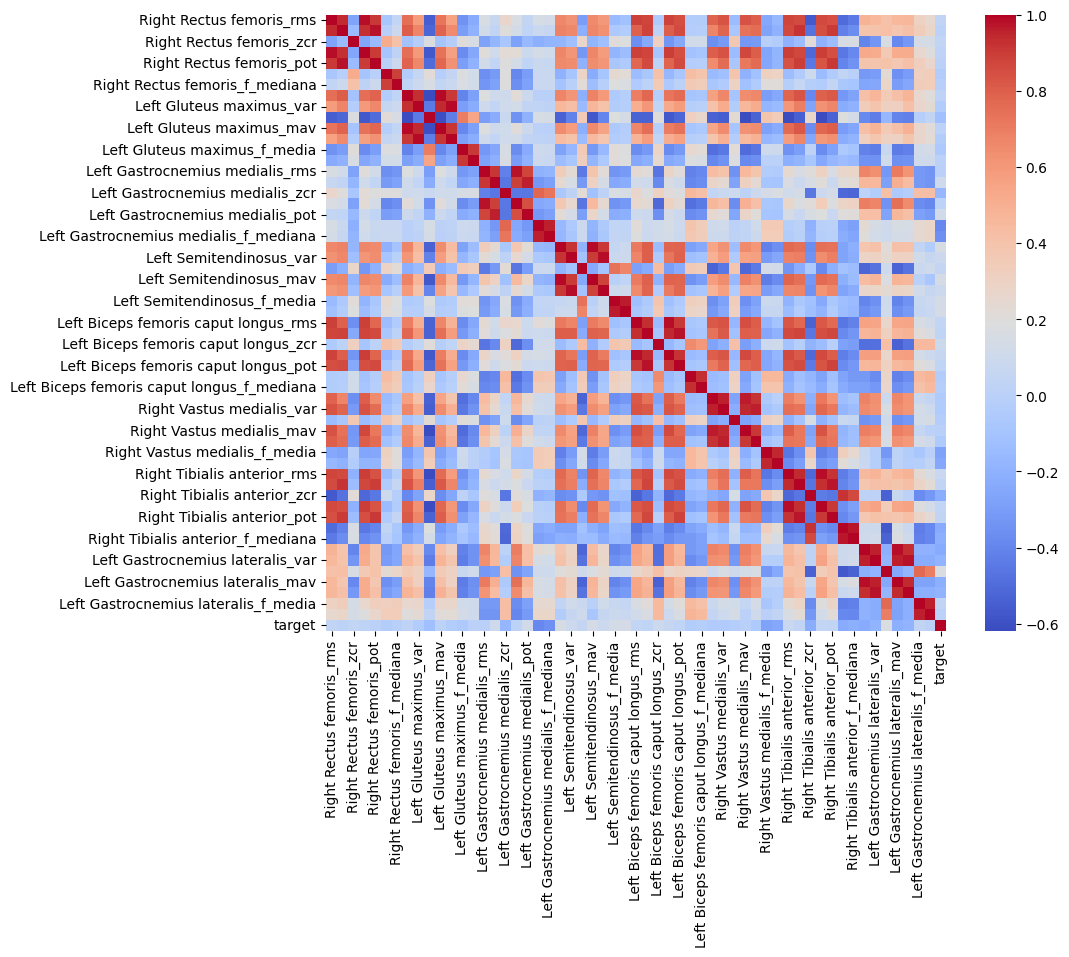

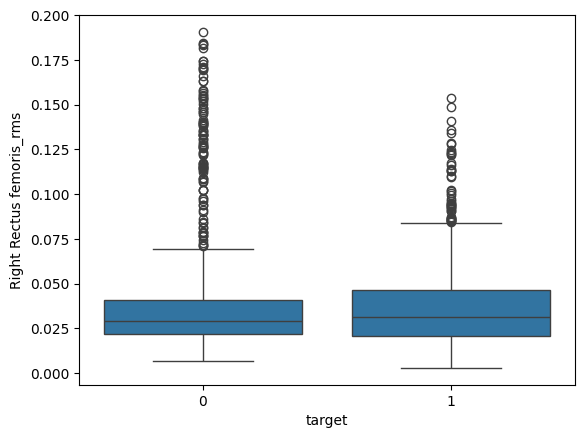

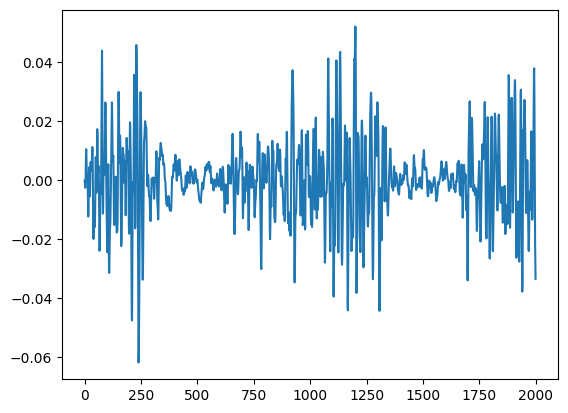

In [7]:
nuevo_df.describe()
nuevo_df['target'].value_counts().plot(kind='bar')
plt.show()
nuevo_df.hist(figsize=(15,12))
plt.show()
plt.figure(figsize=(10,8))
sns.heatmap(nuevo_df.corr(), cmap='coolwarm')
plt.show()
sns.boxplot(x='target', y='Right Rectus femoris_rms', data=nuevo_df)
plt.show()
plt.plot(df['Right Rectus femoris'][:2000])
plt.show()

## Preprocesamiento de datos

Se separan las variables predictoras y la variable objetivo.  
Posteriormente, se divide el dataset en conjuntos de entrenamiento, validación y prueba.

También se aplica normalización para mejorar el desempeño de los modelos.

In [8]:
X = nuevo_df.drop(columns=['target'])
y = nuevo_df['target']

In [9]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Entrenamiento de modelos

Se entrenan diferentes modelos de Machine Learning:

- k-Nearest Neighbors (kNN)
- Decision Tree
- Random Forest
- Gradient Boosting

Estos modelos permiten comparar diferentes enfoques de clasificación.


In [12]:
def evaluar_modelo(nombre, modelo, X_train, y_train, X_val, y_val, X_test, y_test):
    
    modelo.fit(X_train, y_train)
    
    y_train_pred = modelo.predict(X_train)
    y_val_pred   = modelo.predict(X_val)
    y_test_pred  = modelo.predict(X_test)
    
    return {
        'Modelo': nombre,
        'Train Acc': accuracy_score(y_train, y_train_pred),
        'Val Acc': accuracy_score(y_val, y_val_pred),
        'Test Acc': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1': f1_score(y_test, y_test_pred)
    }

## Evaluación de modelos

Se evalúan los modelos utilizando métricas como:

- Accuracy
- Precision
- Recall
- F1-score

Esto permite determinar cuál modelo tiene mejor desempeño.

In [13]:
resultados = []

resultados.append(evaluar_modelo("kNN", KNeighborsClassifier(), X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test))
resultados.append(evaluar_modelo("Decision Tree", DecisionTreeClassifier(), X_train, y_train, X_val, y_val, X_test, y_test))
resultados.append(evaluar_modelo("Random Forest", RandomForestClassifier(), X_train, y_train, X_val, y_val, X_test, y_test))
resultados.append(evaluar_modelo("Gradient Boosting", GradientBoostingClassifier(), X_train, y_train, X_val, y_val, X_test, y_test))

resultados_df = pd.DataFrame(resultados)
resultados_df

,Modelo,Train Acc,Val Acc,Test Acc,Precision,Recall,F1
0,kNN,0.898192,0.850780,0.873614,0.830357,0.709924,0.765432
1,Decision Tree,1.000000,0.821826,0.824834,0.678082,0.755725,0.714801
2,Random Forest,1.000000,0.877506,0.891353,0.847458,0.763359,0.803213
3,Gradient Boosting,0.931494,0.835189,0.864745,0.796610,0.717557,0.755020


## Optimización de hiperparámetros

Se utiliza Grid Search para encontrar la mejor configuración del modelo Random Forest, mejorando su desempeño.


In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

## Red neuronal profunda (DNN)

Se implementa una red neuronal con múltiples capas ocultas para capturar relaciones complejas en los datos.

Se incluye regularización mediante Dropout para evitar overfitting.

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7460 - loss: 0.5465 - val_accuracy: 0.8085 - val_loss: 0.4396
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8054 - loss: 0.4330 - val_accuracy: 0.8018 - val_loss: 0.4169
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8178 - loss: 0.4027 - val_accuracy: 0.8174 - val_loss: 0.3931
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8330 - loss: 0.3843 - val_accuracy: 0.8307 - val_loss: 0.3740
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8411 - loss: 0.3738 - val_accuracy: 0.8352 - val_loss: 0.3637
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8449 - loss: 0.3553 - val_accuracy: 0.8419 - val_loss: 0.3574
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8421 - loss: 0.3510 - val_accuracy: 0.8597 - val_loss: 0.3435
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8516 - loss: 0.3422 - val_accuracy: 0.8619 - val_loss

## Curvas de entrenamiento

Se analizan las curvas de pérdida en entrenamiento y validación para identificar posibles problemas como overfitting o underfitting.

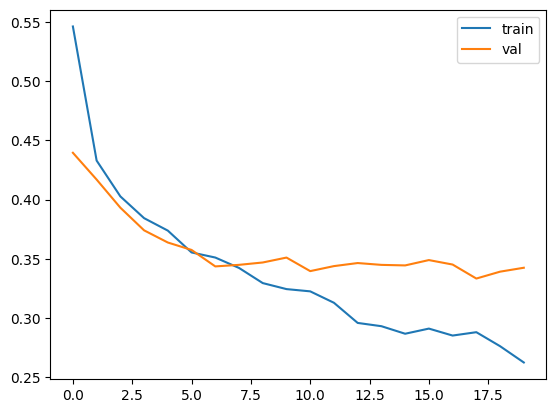

In [17]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

## Red neuronal profunda (DNN)

Se implementa una red neuronal con múltiples capas ocultas para capturar relaciones complejas en los datos.

Se incluye regularización mediante Dropout para evitar overfitting.

In [18]:
from sklearn.metrics import classification_report

y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       320
           1       0.77      0.83      0.80       131

    accuracy                           0.88       451
   macro avg       0.85      0.86      0.86       451
weighted avg       0.88      0.88      0.88       451



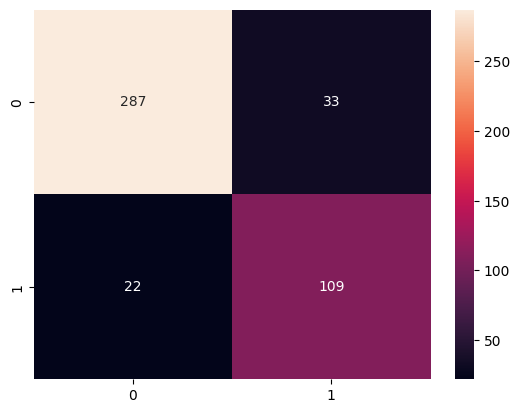

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [20]:
muestra = X_train.mean().values.reshape(1, -1)
muestra_scaled = scaler.transform(muestra)

print("Predicción:", model.predict(muestra_scaled))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicción: [[0.20203033]]


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Conclusiones

Se compararon diferentes modelos para la clasificación de fatiga muscular.

La red neuronal y los modelos de ensamble mostraron mejor desempeño, destacándose por su capacidad de generalización.

La extracción de características fue clave para capturar información relevante de las señales EMG.

Como trabajo futuro, se pueden explorar modelos más complejos y técnicas de optimización avanzadas.